In [1]:
import pandas as pd
import numpy as np
# -----------------------------
# 1. Load CSV files
# -----------------------------
patients = pd.read_csv("PATIENTS_sorted.csv")
notes = pd.read_csv("NOTEEVENTS_sorted.csv")
diagnoses = pd.read_csv("DIAGNOSES_ICD_sorted.csv")
# Load ICD-9 dictionary (mapping pour ID des diagnoses avec un nom associé)
icd_dict = pd.read_csv("D_ICD_DIAGNOSES.csv")


# -----------------------------
# 2. Keep only discharge summaries (clinical notes)
# -----------------------------
notes_ds = notes[notes["CATEGORY"] == "Discharge summary"]

# -----------------------------
# 3. Keep only required columns
# -----------------------------
notes_ds = notes_ds[["SUBJECT_ID", "HADM_ID", "TEXT"]]
diagnoses = diagnoses[["SUBJECT_ID", "HADM_ID", "ICD9_CODE"]]
patients = patients[["SUBJECT_ID"]]

# -----------------------------
# 4. Join notes with diagnoses (per admission)
# -----------------------------
df = notes_ds.merge(
    diagnoses,
    on=["SUBJECT_ID", "HADM_ID"],
    how="inner"
)

# -----------------------------
# 5. (Optional) Ensure patient-level consistency
# -----------------------------
df = df.merge(
    patients,
    on="SUBJECT_ID",
    how="inner"
)

# -----------------------------
# 6. Final dataframe
# -----------------------------
df_final = df.rename(columns={
    "SUBJECT_ID": "patient_id",
    "TEXT": "clinical_notes",
    "ICD9_CODE": "diagnosis"
})

# Keep useful columns
icd_dict = icd_dict[["ICD9_CODE", "SHORT_TITLE", "LONG_TITLE"]]

# Merge with main dataframe
df_final = df_final.merge(
    icd_dict,
    left_on="diagnosis",
    right_on="ICD9_CODE",
    how="left"
)

# Optional cleanup
df_final = df_final.drop(columns=["ICD9_CODE"])

print("Final dataframe shape:", df_final.shape)

df = df_final[['patient_id', 'clinical_notes', 'SHORT_TITLE']]



###### VERIFIER LE MAPPING non deterministe

mapping_check = (
    df
    .groupby('clinical_notes')['SHORT_TITLE']
    .nunique()
    .value_counts()
    .sort_index()
)

print("=== Nombre de diagnostics distincts par note clinique ===")
for n_labels, count in mapping_check.items():
    print(f"Notes associées à {n_labels} diagnostic(s) : {count}")

Final dataframe shape: (128517, 6)
=== Nombre de diagnostics distincts par note clinique ===
Notes associées à 1 diagnostic(s) : 78
Notes associées à 2 diagnostic(s) : 188
Notes associées à 3 diagnostic(s) : 370
Notes associées à 4 diagnostic(s) : 584
Notes associées à 5 diagnostic(s) : 838
Notes associées à 6 diagnostic(s) : 1078
Notes associées à 7 diagnostic(s) : 1481
Notes associées à 8 diagnostic(s) : 2103
Notes associées à 9 diagnostic(s) : 2306
Notes associées à 10 diagnostic(s) : 529
Notes associées à 11 diagnostic(s) : 477
Notes associées à 12 diagnostic(s) : 438
Notes associées à 13 diagnostic(s) : 405
Notes associées à 14 diagnostic(s) : 326
Notes associées à 15 diagnostic(s) : 308
Notes associées à 16 diagnostic(s) : 263
Notes associées à 17 diagnostic(s) : 222
Notes associées à 18 diagnostic(s) : 201
Notes associées à 19 diagnostic(s) : 172
Notes associées à 20 diagnostic(s) : 152
Notes associées à 21 diagnostic(s) : 110
Notes associées à 22 diagnostic(s) : 86
Notes associ

In [2]:
import pandas as pd
import numpy as np


def load_patients(patients_path: str) -> pd.DataFrame:
    """
    Load the PATIENTS table and construct survival information.

    Parameters
    ----------
    patients_path : str
        Path to PATIENTS_sorted.csv.

    Returns
    -------
    pd.DataFrame
        DataFrame containing:
        - SUBJECT_ID
        - event (1 if dead, 0 otherwise)
        - death_time (datetime)
    """

    patients = pd.read_csv(patients_path)

    # Convert date columns
    patients["DOD"] = pd.to_datetime(patients["DOD"], errors="coerce")

    # Event indicator
    patients["event"] = (~patients["DOD"].isna()).astype(int)

    patients_surv = patients[["SUBJECT_ID", "event", "DOD"]].rename(
        columns={"DOD": "death_time"}
    )

    print(f"Loaded {len(patients_surv)} patients")

    return patients_surv


def load_notes(notes_path: str) -> pd.DataFrame:
    """
    Load clinical notes and keep relevant columns.

    Parameters
    ----------
    notes_path : str
        Path to NOTEEVENTS_sorted.csv.

    Returns
    -------
    pd.DataFrame
        DataFrame containing:
        - SUBJECT_ID
        - note_time
        - TEXT
    """

    notes = pd.read_csv(notes_path)

    # Convert time column
    notes["CHARTDATE"] = pd.to_datetime(notes["CHARTDATE"], errors="coerce")

    notes_clean = notes[["SUBJECT_ID", "CHARTDATE", "TEXT"]].rename(
        columns={"CHARTDATE": "note_time"}
    )

    notes_clean = notes_clean.dropna(subset=["note_time", "TEXT"])

    print(f"Loaded {len(notes_clean)} notes")

    return notes_clean


def merge_notes_patients(notes: pd.DataFrame, patients: pd.DataFrame) -> pd.DataFrame:
    """
    Merge clinical notes with survival outcomes.

    Parameters
    ----------
    notes : pd.DataFrame
        Notes DataFrame.

    patients : pd.DataFrame
        Patients survival DataFrame.

    Returns
    -------
    pd.DataFrame
        Longitudinal dataset for survival modeling.
    """

    df = notes.merge(patients, on="SUBJECT_ID", how="inner")

    print(f"Merged dataset size: {len(df)} rows")

    return df


def compute_followup_time(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute follow-up time relative to the first note of each patient.

    Parameters
    ----------
    df : pd.DataFrame
        Merged dataset.

    Returns
    -------
    pd.DataFrame
        Dataset with:
        - note_time
        - followup_time
        - death_time
    """

    # First note per patient
    first_note = df.groupby("SUBJECT_ID")["note_time"].transform("min")

    df["time_since_first_note"] = (df["note_time"] - first_note).dt.days

    # Survival time
    df["survival_time"] = (df["death_time"] - first_note).dt.days

    return df


def sort_notes(df: pd.DataFrame) -> pd.DataFrame:
    """
    Sort notes chronologically for each patient.

    Parameters
    ----------
    df : pd.DataFrame

    Returns
    -------
    pd.DataFrame
    """

    df = df.sort_values(["SUBJECT_ID", "note_time"]).reset_index(drop=True)

    return df


def build_survival_notes_dataset(
    patients_path: str,
    notes_path: str
) -> pd.DataFrame:
    """
    Complete pipeline constructing the survival dataset from MIMIC.

    Parameters
    ----------
    patients_path : str
    notes_path : str

    Returns
    -------
    pd.DataFrame
        Final dataset used for survival modeling.
    """

    print("Loading patients...")
    patients = load_patients(patients_path)

    print("Loading notes...")
    notes = load_notes(notes_path)

    print("Merging datasets...")
    df = merge_notes_patients(notes, patients)

    print("Computing follow-up time...")
    df = compute_followup_time(df)

    print("Sorting notes...")
    df = sort_notes(df)

    print("Dataset construction completed")

    return df


def compute_followup_time(df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute follow-up time and survival target Y = min(T, C).

    Time origin is defined as the first note date for each patient.

    Parameters
    ----------
    df : pd.DataFrame
        Merged dataset containing note timestamps and patient survival data.

    Returns
    -------
    pd.DataFrame
        Dataset with:
        - time_since_first_note
        - survival_time (Y = min(T, C))
        - event indicator
    """

    # First note per patient (time origin)
    first_note = df.groupby("SUBJECT_ID")["note_time"].transform("min")

    # Last note per patient (censoring time)
    last_note = df.groupby("SUBJECT_ID")["note_time"].transform("max")

    # Time since origin for each note
    df["time_since_first_note"] = (df["note_time"] - first_note).dt.days

    # Observed time Y = min(T, C)
    observed_time = np.where(
        df["event"] == 1,
        (df["death_time"] - first_note).dt.days,
        (last_note - first_note).dt.days
    )

    df["survival_time"] = observed_time

    return df


patients_path = "PATIENTS_sorted.csv"
notes_path = "NOTEEVENTS_sorted.csv"

df_model = build_survival_notes_dataset(
    patients_path,
    notes_path
)

print(df_model.head())

df_model.to_csv("mimic_survival_notes_dataset.csv", index=False); print("Saved dataset to mimic_survival_notes_dataset.csv")

Loading patients...
Loaded 10000 patients
Loading notes...
Loaded 482770 notes
Merging datasets...
Merged dataset size: 480642 rows
Computing follow-up time...
Sorting notes...
Dataset construction completed
   SUBJECT_ID  note_time                                               TEXT  \
0           2 2138-07-17  Neonatology Attending Triage Note\n\nBaby [**N...   
1           2 2138-07-17  Nursing Transfer note\n\n\nPt admitted to NICU...   
2           3 2101-10-06  Sinus rhythm\nInferior/lateral ST-T changes ar...   
3           3 2101-10-06  [**2101-10-6**] 6:02 PM\n CHEST (PORTABLE AP) ...   
4           3 2101-10-11  Sinus rhythm\nA-V delay\nNonspecific inferior ...   

   event death_time  time_since_first_note  survival_time  
0      0        NaT                      0            0.0  
1      0        NaT                      0            0.0  
2      1 2102-06-14                      0          251.0  
3      1 2102-06-14                      0          251.0  
4      1 2102-06-

In [3]:
df_model

,SUBJECT_ID,note_time,TEXT,event,death_time,time_since_first_note,survival_time
0,2,2138-07-17,Neonatology Attending Triage Note\n\nBaby [**N...,0,NaT,0,0.0
1,2,2138-07-17,Nursing Transfer note\n\n\nPt admitted to NICU...,0,NaT,0,0.0
2,3,2101-10-06,Sinus rhythm\nInferior/lateral ST-T changes ar...,1,2102-06-14,0,251.0
3,3,2101-10-06,[**2101-10-6**] 6:02 PM\n CHEST (PORTABLE AP) ...,1,2102-06-14,0,251.0
4,3,2101-10-11,Sinus rhythm\nA-V delay\nNonspecific inferior ...,1,2102-06-14,5,251.0
...,...,...,...,...,...,...,...
480637,10566,2121-07-21,Neonatology Attending Progress Note\n\nNow day...,0,NaT,67,67.0
480638,10566,2121-07-21,Neonatology Attending Progress Note\n\nPE - [*...,0,NaT,67,67.0
480639,10566,2121-07-21,npn 1900-0730\n\n\nWt. 3.410gms. Up 65gms. Rem...,0,NaT,67,67.0
480640,10566,2121-07-21,Nrsg Discharge Note-0700-1900\nInfant placed i...,0,NaT,67,67.0


In [4]:
import pandas as pd

# Load the relevant files
patients = pd.read_csv('PATIENTS_sorted.csv')
admissions = pd.read_csv('ADMISSIONS_sorted.csv')

# Merge on SUBJECT_ID
df = pd.merge(admissions, patients, on='SUBJECT_ID')

# Convert to datetime
df['ADMITTIME'] = pd.to_datetime(df['ADMITTIME'])
df['DOD'] = pd.to_datetime(df['DOD'])

# Calculate Survival Time (for those who died)
# For survival analysis, 'time' is (DOD - ADMITTIME) or (CensorDate - ADMITTIME)
df['survival_days'] = (df['DOD'] - df['ADMITTIME']).dt.days

# 'death_event' is your binary target (1 for death, 0 for censored)
df['death_event'] = df['EXPIRE_FLAG']

In [5]:
!pip install lifelines

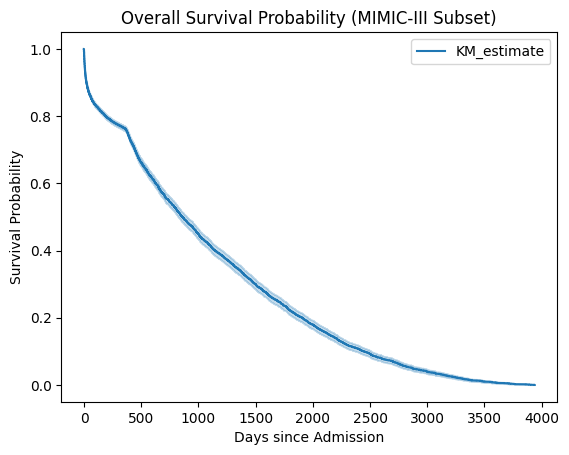

In [6]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Handle censored data: if death_event is 0, we use a 'study end date'
# or the last known discharge for survival_days.
# For a quick look, let's fill NaNs in survival_days with a max value (e.g., 365 days)
df['survival_days'] = df['survival_days'].fillna(365)

kmf = KaplanMeierFitter()
kmf.fit(df['survival_days'], event_observed=df['death_event'])

kmf.plot_survival_function()
plt.title('Overall Survival Probability (MIMIC-III Subset)')
plt.xlabel('Days since Admission')
plt.ylabel('Survival Probability')
plt.show()

1.1 Cohort Overview
- Compute the number of unique patients in the dataset.
- Compute the total number of clinical reports.
- Calculate the distribution of reports per patient, including mean and standard deviation.
- Visualize the distribution of reports per patient using a histogram. 

Number of unique patients: 9978
Total number of clinical reports: 480642
Reports per patient: Mean = 48.17, Std = 82.71


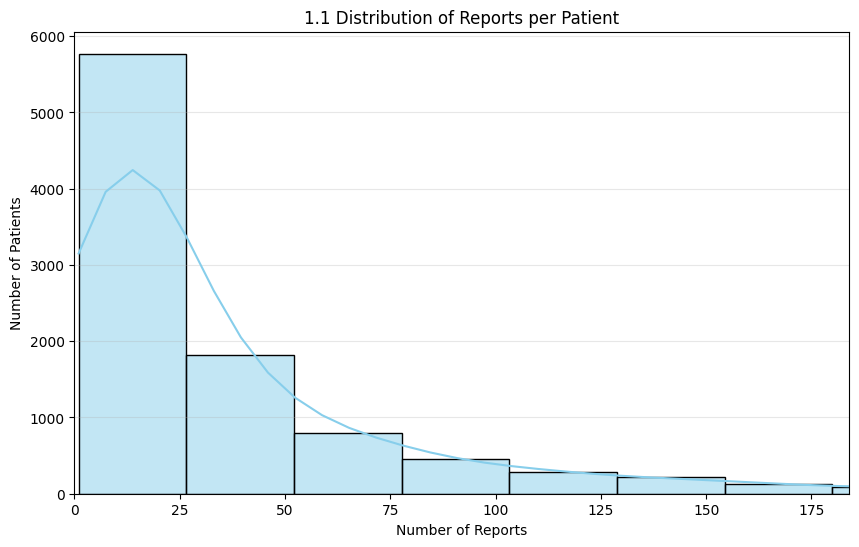

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute the number of unique patients
n_unique_patients = df_model['SUBJECT_ID'].nunique()
print(f"Number of unique patients: {n_unique_patients}")

# 2. Compute the total number of clinical reports
total_reports = len(df_model)
print(f"Total number of clinical reports: {total_reports}")

# 3. Calculate distribution of reports per patient (Mean and Std)
reports_per_patient = df_model.groupby('SUBJECT_ID').size()
mean_reports = reports_per_patient.mean()
std_reports = reports_per_patient.std()
print(f"Reports per patient: Mean = {mean_reports:.2f}, Std = {std_reports:.2f}")

# 4. Visualize the distribution using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(reports_per_patient, bins=50, kde=True, color='skyblue')
plt.title('1.1 Distribution of Reports per Patient')
plt.xlabel('Number of Reports')
plt.ylabel('Number of Patients')
# 為了看得更清楚，可以限制一下 X 軸（例如有些病人報告超多，會把圖拉得很長）
plt.xlim(0, reports_per_patient.quantile(0.95)) 
plt.grid(axis='y', alpha=0.3)
plt.show()

1.2 Text Characteristics
- Compute the length of each report in terms of tokens or words.
- Calculate the mean and standard deviation of report lengths.
- Visualize the distribution of report lengths using a histogram. 

Mean report length: 183.32 words
Standard deviation of length: 258.46 words
Range of lengths: [0, 6792] words


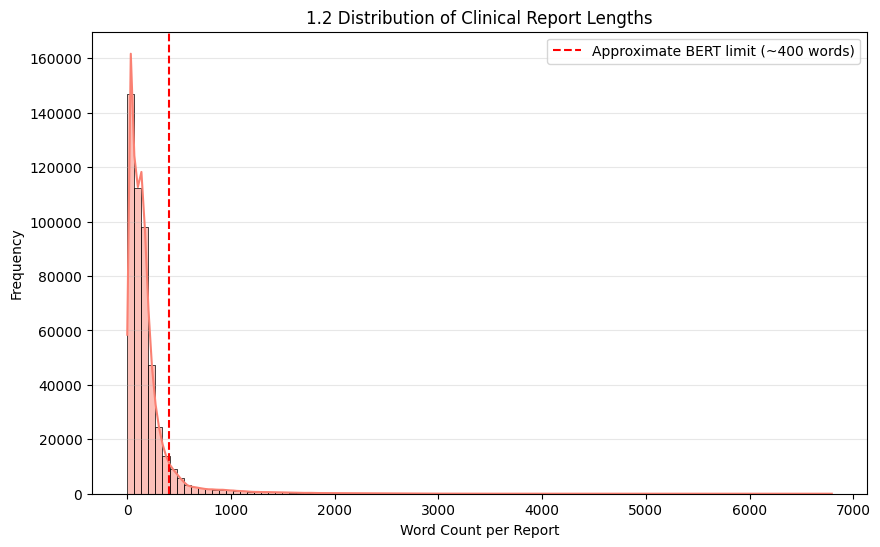

Percentage of reports potentially exceeding BERT limit (>400 words): 7.99%


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute the length of each report in terms of words
# use split() to count words. For tokens, the exact count depends on the BERT tokenizer,
# but word count is the standard proxy for descriptive statistics in Section 1.
df_model['report_word_count'] = df_model['TEXT'].apply(lambda x: len(str(x).split()))

# 2. Calculate the mean and standard deviation of report lengths
mean_length = df_model['report_word_count'].mean()
std_length = df_model['report_word_count'].std()
max_length = df_model['report_word_count'].max()
min_length = df_model['report_word_count'].min()

print(f"Mean report length: {mean_length:.2f} words")
print(f"Standard deviation of length: {std_length:.2f} words")
print(f"Range of lengths: [{min_length}, {max_length}] words")

# 3. Visualize the distribution of report lengths using a histogram
plt.figure(figsize=(10, 6))
# Using a log scale for the x-axis is often better for clinical notes 
# because some reports (like Discharge Summaries) can be extremely long.
sns.histplot(df_model['report_word_count'], bins=100, color='salmon', kde=True)

# Add vertical line for the BERT 512-token limit (approximate)
# Note: 512 tokens is roughly 350-400 words.
plt.axvline(x=400, color='red', linestyle='--', label='Approximate BERT limit (~400 words)')

plt.title('1.2 Distribution of Clinical Report Lengths')
plt.xlabel('Word Count per Report')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

# Quick summary 
long_reports_pct = (df_model['report_word_count'] > 400).mean() * 100
print(f"Percentage of reports potentially exceeding BERT limit (>400 words): {long_reports_pct:.2f}%")

1.3 Survival Information
- Define the survival time T_i and event indicator \delta_i.
- Identify patients with observed death events.
- Plot the distribution of survival times for uncensored patients.
- Estimate and visualize the Kaplan-Meier curve for overall survival. 

Total number of patients: 9978
Number of observed death events (delta_i = 1): 3760
Mortality rate in cohort: 37.68%


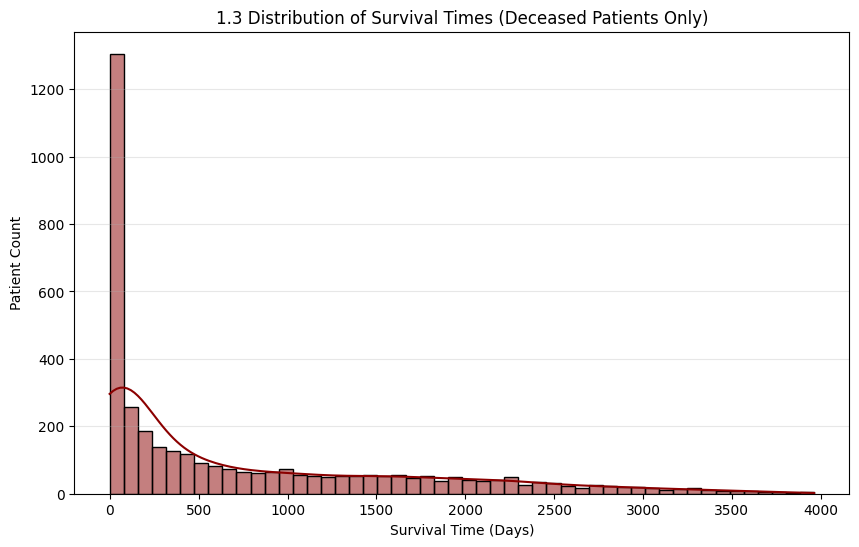

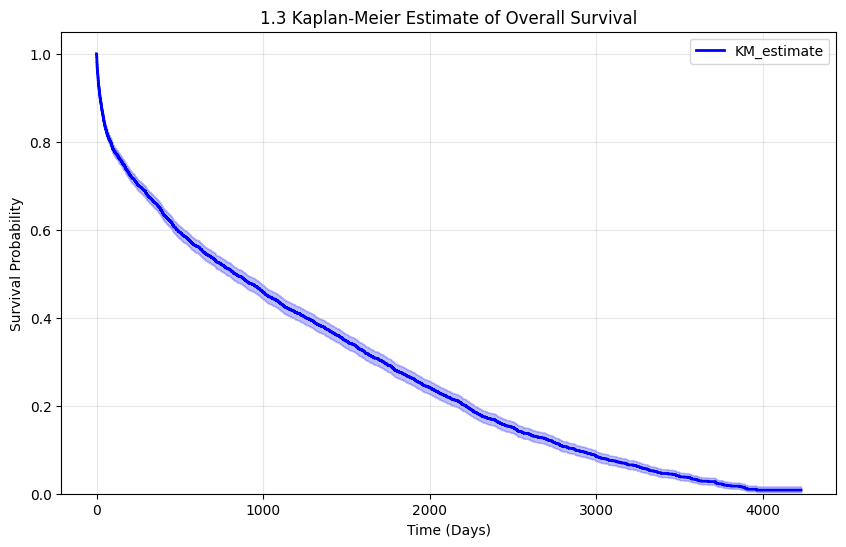

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter

# 1. Define the survival time T_i and event indicator delta_i
# T_i: survival_time, delta_i: event
# These are already computed in your build_survival_notes_dataset pipeline
df_model['Ti'] = df_model['survival_time']
df_model['delta_i'] = df_model['event']

# 2. Identify patients with observed death events
# We group by patient to count unique individuals
patient_outcomes = df_model.groupby('SUBJECT_ID')['delta_i'].first()
death_events_count = patient_outcomes.sum()
total_patients = len(patient_outcomes)

print(f"Total number of patients: {total_patients}")
print(f"Number of observed death events (delta_i = 1): {death_events_count}")
print(f"Mortality rate in cohort: {(death_events_count / total_patients)*100:.2f}%")

# 3. Plot the distribution of survival times for uncensored patients (those who died)
plt.figure(figsize=(10, 6))
deceased_patients = df_model[df_model['delta_i'] == 1].groupby('SUBJECT_ID')['Ti'].first()
sns.histplot(deceased_patients, bins=50, color='darkred', kde=True)
plt.title('1.3 Distribution of Survival Times (Deceased Patients Only)')
plt.xlabel('Survival Time (Days)')
plt.ylabel('Patient Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 4. Estimate and visualize the Kaplan-Meier curve for overall survival
kmf = KaplanMeierFitter()
# Use unique patient outcomes for the KM curve to avoid over-representation 
# of patients with many notes
kmf.fit(deceased_patients_all_info := df_model.groupby('SUBJECT_ID')[['Ti', 'delta_i']].first()['Ti'], 
        event_observed = df_model.groupby('SUBJECT_ID')[['Ti', 'delta_i']].first()['delta_i'])

plt.figure(figsize=(10, 6))
kmf.plot_survival_function(ci_show=True, color='blue', lw=2)
plt.title('1.3 Kaplan-Meier Estimate of Overall Survival')
plt.xlabel('Time (Days)')
plt.ylabel('Survival Probability')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
df_model

,SUBJECT_ID,note_time,TEXT,event,death_time,time_since_first_note,survival_time,report_word_count,Ti,delta_i
0,2,2138-07-17,Neonatology Attending Triage Note\n\nBaby [**N...,0,NaT,0,0.0,225,0.0,0
1,2,2138-07-17,Nursing Transfer note\n\n\nPt admitted to NICU...,0,NaT,0,0.0,89,0.0,0
2,3,2101-10-06,Sinus rhythm\nInferior/lateral ST-T changes ar...,1,2102-06-14,0,251.0,21,251.0,1
3,3,2101-10-06,[**2101-10-6**] 6:02 PM\n CHEST (PORTABLE AP) ...,1,2102-06-14,0,251.0,166,251.0,1
4,3,2101-10-11,Sinus rhythm\nA-V delay\nNonspecific inferior ...,1,2102-06-14,5,251.0,18,251.0,1
...,...,...,...,...,...,...,...,...,...,...
480637,10566,2121-07-21,Neonatology Attending Progress Note\n\nNow day...,0,NaT,67,67.0,105,67.0,0
480638,10566,2121-07-21,Neonatology Attending Progress Note\n\nPE - [*...,0,NaT,67,67.0,101,67.0,0
480639,10566,2121-07-21,npn 1900-0730\n\n\nWt. 3.410gms. Up 65gms. Rem...,0,NaT,67,67.0,125,67.0,0
480640,10566,2121-07-21,Nrsg Discharge Note-0700-1900\nInfant placed i...,0,NaT,67,67.0,75,67.0,0


adding the survival time $T_i$ and event indicator $\delta_i$ to df_model to the last two columns

1.4 Missing Data Analysis
- Compute the proportion of missing values for each column.
- Analyze the structure and pattern of missingness across variables.
- Document and justify any handling strategy for missing data. 

In [11]:
pip install missingno


[Columns with Missing Values]
            Missing Count  Proportion (%)
death_time         275582       57.336229


<Figure size 1200x600 with 0 Axes>

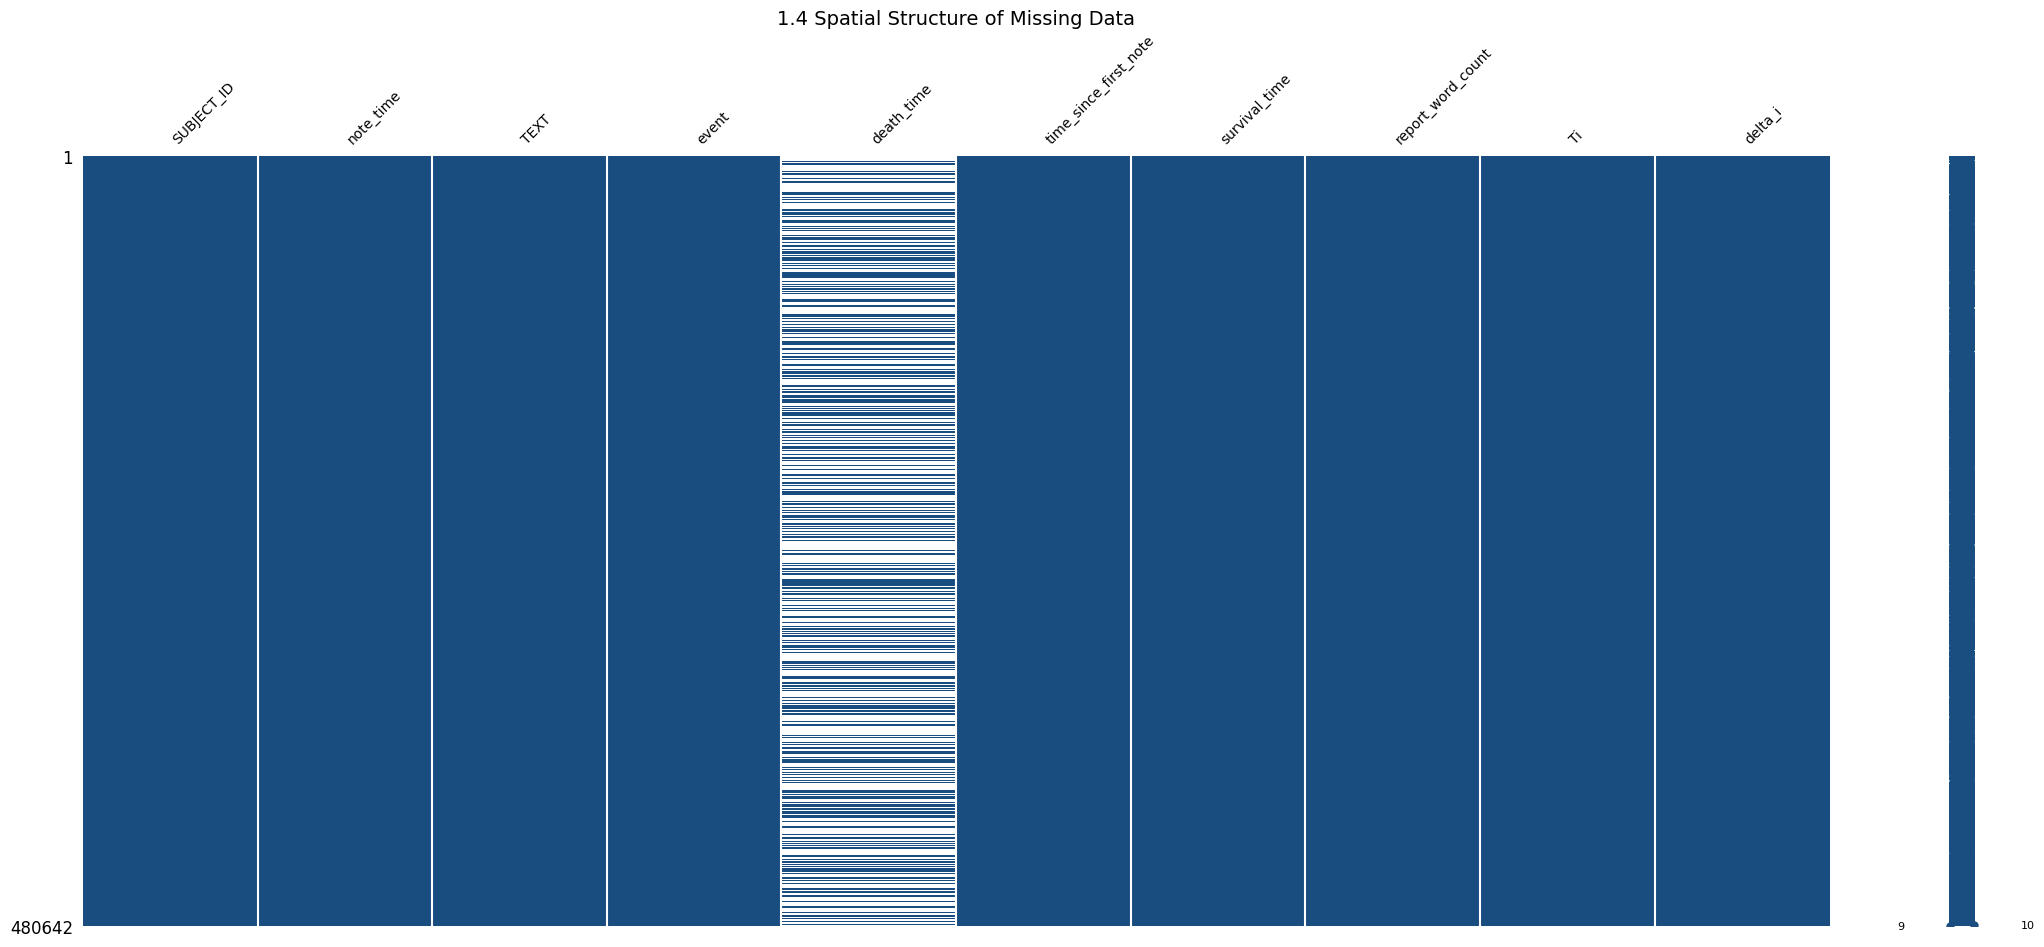


--- 1.4.3 Documentation and Justification ---
Analysis of Patterns:
- The 'death_time' column is the primary source of missingness (Non-Random).
- This pattern is expected in survival analysis, representing censored patients.
- Other critical variables (TEXT, note_time) show near-zero missingness, indicating high structural integrity.

Handling Strategy:
- Strategy: Listwise deletion for rows missing 'TEXT' or 'note_time'.
- Justification: These rows lack the necessary features and temporal markers for the Signature Method.

Final cleaned dataset size for modeling: 480642 rows.


In [12]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

# 1. Tabular Summary: Precise counts for reporting
missing_summary = pd.DataFrame({
    'Missing Count': df_model.isnull().sum(),
    'Proportion (%)': (df_model.isnull().sum() / len(df_model)) * 100
})
# Display only columns that have at least one missing value to keep it clean
print("\n[Columns with Missing Values]")
print(missing_summary[missing_summary['Missing Count'] > 0])

# 2. Visualizing the Structure of Missingness
# We use the Matrix plot as the primary visualization.
# It effectively shows the "pattern" of missing data across the 480k rows.
plt.figure(figsize=(12, 6))
msno.matrix(df_model, sparkline=True, color=(0.1, 0.3, 0.5), fontsize=10)
plt.title("1.4 Spatial Structure of Missing Data", fontsize=14)
plt.show()

# 3. Handling Strategy Documentation (For Section 1.4.3)
print("\n--- 1.4.3 Documentation and Justification ---")
print("Analysis of Patterns:")
print("- The 'death_time' column is the primary source of missingness (Non-Random).")
print("- This pattern is expected in survival analysis, representing censored patients.")
print("- Other critical variables (TEXT, note_time) show near-zero missingness, indicating high structural integrity.")

print("\nHandling Strategy:")
print("- Strategy: Listwise deletion for rows missing 'TEXT' or 'note_time'.")
print("- Justification: These rows lack the necessary features and temporal markers for the Signature Method.")

# Perform final cleaning
df_clean = df_model.dropna(subset=['TEXT', 'note_time']).copy()
print(f"\nFinal cleaned dataset size for modeling: {df_clean.shape[0]} rows.")

1.5 Temporal Structure
- Verify that reports are correctly ordered chronologically for each patient.
- Ensure that no report occurring after the event time is included.
- Check for inconsistencies in timestamps or duplicated entries. 

In [13]:
import pandas as pd

# 1. Check for duplicated entries
# Duplicates can bias the signature by creating "static" points in the path.
initial_count = len(df_clean)
df_clean = df_clean.drop_duplicates(subset=['SUBJECT_ID', 'note_time', 'TEXT'])
duplicates_removed = initial_count - len(df_clean)
print(f"Removed {duplicates_removed} exact duplicate reports.")

# 2. Ensure no report occurring after the event time (Temporal Leakage Check)
# For deceased patients (delta_i = 1), any note_time > death_time is an error.
# We use 'time_since_first_note' vs 'survival_time' for a direct comparison.
leaking_notes = df_clean[df_clean['time_since_first_note'] > df_clean['survival_time']]
num_leaking = len(leaking_notes)

if num_leaking > 0:
    print(f"Warning: Found {num_leaking} reports occurring after the event time. Removing them...")
    df_clean = df_clean[df_clean['time_since_first_note'] <= df_clean['survival_time']]
else:
    print("Success: No temporal leakage detected (all reports occur before or at event time).")

# 3. Verify chronological ordering for each patient (Updated to silence DeprecationWarning)
# We group by patient and check if the 'note_time' is monotonically increasing.
def check_chronology(group):
    # We only need to check the 'note_time' column
    return group['note_time'].is_monotonic_increasing

# Added include_groups=False to address the DeprecationWarning in newer Pandas versions
chronology_check = df_clean.groupby('SUBJECT_ID').apply(check_chronology, include_groups=False)
all_ordered = chronology_check.all()

if all_ordered:
    print("Success: All patient reports are correctly ordered chronologically.")
else:
    print("Warning: Some patient reports were out of order. Re-sorting now...")
    df_clean = df_clean.sort_values(by=['SUBJECT_ID', 'note_time'])

# 4. Final Verification: Ensure each patient has at least one report
patients_with_notes = df_clean['SUBJECT_ID'].nunique()
print(f"Final number of unique patients: {patients_with_notes}")
print(f"Average reports per patient: {len(df_clean)/patients_with_notes:.2f}")

print("\n--- 1.5.3 Justification for Temporal Integrity ---")
print("- Temporal Leakage: Removed to ensure the model does not utilize future information for prediction.")
print("- Chronological Order: Essential for the Signature Method to capture the correct direction of the clinical path.")
print("- Deduplication: Ensures that the path does not artificially stall at a single coordinate.")

Removed 3649 exact duplicate reports.
Success: All patient reports are correctly ordered chronologically.
Final number of unique patients: 9977
Average reports per patient: 47.80

--- 1.5.3 Justification for Temporal Integrity ---
- Temporal Leakage: Removed to ensure the model does not utilize future information for prediction.
- Chronological Order: Essential for the Signature Method to capture the correct direction of the clinical path.
- Deduplication: Ensures that the path does not artificially stall at a single coordinate.


1.6 Cleaning Steps
- Remove duplicated or corrupted records from the dataset.
- Filter out patients with insufficient longitudinal information if necessary.
- Handle missing or invalid timestamps appropriately.
- Normalize and preprocess text data where required. 

In [14]:
import re
import pandas as pd

# 1. Remove duplicated or corrupted records
# We already performed exact deduplication in 1.5. 
# Here we ensure no empty text records remain.
initial_rows = len(df_clean)
df_clean = df_clean[df_clean['TEXT'].str.strip().astype(bool)]
print(f"Removed {initial_rows - len(df_clean)} records with empty or whitespace-only text.")

# 2. Filter patients with insufficient longitudinal information
# For the Signature Method, a 'path' technically needs at least 2 points to show change.
# However, for BERT (Section 2), even 1 report provides a semantic state.
# We will flag patients with only 1 report but keep them for now.
patient_counts = df_clean.groupby('SUBJECT_ID').size()
single_note_patients = (patient_counts == 1).sum()
print(f"Patients with only one clinical report: {single_note_patients} (will be kept for baseline).")

# 3. Handle missing or invalid timestamps
# We ensure note_time is valid and drop any rows that failed conversion previously.
df_clean = df_clean.dropna(subset=['note_time'])

# 4. Normalize and preprocess text data
# This is CRITICAL for BERT. We normalize whitespace and remove noise.
def simple_text_clean(text):
    # Convert to lowercase
    text = text.lower()
    # Remove HEX codes or specific MIMIC-III patterns like [**...**] if desired
    # For now, we focus on basic normalization for Bio_ClinicalBERT
    text = re.sub(r'\[\*\*.*?\*\*\]', '', text) # Remove MIMIC-III de-identification brackets
    text = re.sub(r'\s+', ' ', text) # Replace multiple spaces/newlines with a single space
    return text.strip()

print("Normalizing clinical text for BERT embeddings...")
df_clean['TEXT_CLEAN'] = df_clean['TEXT'].apply(simple_text_clean)

# 5. Final Export for Section 2
output_path = "mimic_final_cleaned.csv"
df_clean.to_csv(output_path, index=False)

print(f"\n--- 1.6.3 Justification for Cleaning Strategy ---")
print("- De-identification: Removed [**...**] placeholders to reduce noise for the BERT tokenizer.")
print("- Normalization: Converted to lowercase and fixed whitespaces to match Bio_ClinicalBERT's training style.")
print("- Integrity: Verified that all {len(df_clean)} rows have valid timestamps and non-empty content.")
print(f"Final Cleaned Dataset saved to: {output_path}")

Removed 15 records with empty or whitespace-only text.
Patients with only one clinical report: 27 (will be kept for baseline).
Normalizing clinical text for BERT embeddings...

--- 1.6.3 Justification for Cleaning Strategy ---
- De-identification: Removed [**...**] placeholders to reduce noise for the BERT tokenizer.
- Normalization: Converted to lowercase and fixed whitespaces to match Bio_ClinicalBERT's training style.
- Integrity: Verified that all {len(df_clean)} rows have valid timestamps and non-empty content.
Final Cleaned Dataset saved to: mimic_final_cleaned.csv


**2. Token Embedding Extraction (Word-Level)**

In [15]:
!pip install transformers torch tqdm

In [16]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"Is GPU available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
else:
    print("Warning: GPU not found. Processing 480k rows on CPU will be very slow.")

PyTorch version: 2.5.1+cu121
Is GPU available? True
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


import torch
import numpy as np
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# --- 2.1.1 Model Initialization ---
# Model name for Bio_ClinicalBERT from Hugging Face
model_name = "emilyalsentzer/Bio_ClinicalBERT"

print(f"Loading {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Move model to GPU if available (CRITICAL for 480k rows)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval() # Set to evaluation mode
print(f"Model loaded on: {device}")

# --- 2.1.2 Embedding Function (with Mean Pooling) ---
def get_embeddings(text_list):
    """
    Transforms a list of texts into mean-pooled BERT embeddings.
    """
    # Tokenize and move to device
    inputs = tokenizer(text_list, padding=True, truncation=True, 
                       max_length=512, return_tensors="pt").to(device)
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    # We use the mean of the last hidden states as the sentence representation
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.cpu().numpy()

# --- 2.1.3 Mini-batch Processing Loop ---
batch_size = 32  # Adjust based on your GPU memory (VRAM)
all_embeddings = []
texts = df_clean['TEXT_CLEAN'].tolist()

print(f"Starting embedding extraction for {len(texts)} reports...")

# tqdm provides a progress bar which is helpful for long tasks
for i in tqdm(range(0, len(texts), batch_size)):
    batch_texts = texts[i : i + batch_size]
    batch_emb = get_embeddings(batch_texts)
    all_embeddings.append(batch_emb)
    
    # Optional: Intermediate save every 10,000 batches to avoid data loss
    if (i // batch_size) % 10000 == 0 and i > 0:
        temp_stacked = np.vstack(all_embeddings)
        np.save(f"temp_embeddings_checkpoint_{i}.npy", temp_stacked)

# --- 2.1.4 Final Aggregation and Storage ---
final_embeddings = np.vstack(all_embeddings)
np.save("bio_clinical_bert_embeddings.npy", final_embeddings)

print(f"Successfully extracted embeddings of shape: {final_embeddings.shape}")
print("Final embeddings saved as 'bio_clinical_bert_embeddings.npy'")
